# CommuNiche resolve the niche-dependent CD8+ cells state

Benefit from the interpretation of communication-defined niches, in this experiment, we analyze CD8+ T cells across tumor-associated niches: invasive tumor margins (niche 1), immune recruitment regions (niche 2), and DCIS boundaries (niche 7).

**workflow**
1. Loading datasets and niche identification results.
2. Correlation with the communication programs.
3. Obtaining the neighboring cell types and LR

## Loading datasets and niche identification results
Due the analysis of the communication-defined niches in the tutorial, we directly load the niche label and the file provided in the demo folder.


In [5]:
import anndata as ad
import os
import scanpy as sc
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import pandas as pd
import numpy as np
import CommuNiche as CN

### load datasets
data_path_ori = 'D:/Experiment/Communication_domain/experiment_version3/BC/dataset/BC_adata_original.h5ad'
data_path_lr = 'D:/Experiment/Communication_domain/experiment_version3/BC/dataset/lr_prior_filter.txt'


BC = sc.read_h5ad(data_path_ori)
CN.utils.normalize_then_clip(BC, 95)


lr_prior = pd.read_table(data_path_lr, sep = '\t')
lr_prior['from'] = lr_prior['from'].astype(str)
lr_prior['to'] = lr_prior['to'].astype(str)

gene_all = BC.var_names.values
Ligand_all = lr_prior['from'].unique()
Receptor_all = lr_prior['to'].unique()
intersect_genes = np.intersect1d(np.union1d(Ligand_all, Receptor_all), gene_all)
BC_filter = BC[:, list(intersect_genes)].copy()
l_index = CN.utils.search_index(arr1=intersect_genes, arr2 = lr_prior['from'])
r_index = CN.utils.search_index(arr1=intersect_genes, arr2 = lr_prior['to'])
lr_prior_index = CN.utils.integrate_set(l_index, r_index)
lr_prior_filter = lr_prior.iloc[lr_prior_index]


###

spatial_coordinate = BC_filter.obsm['spatial']
ad_matrix, _, _, _, _, _ = CN.utils.cal_K_neighboorhood(spatial_coordinate, k=10)
row_sums = ad_matrix.getnnz(axis=1)
nonzero_rows = np.where(row_sums != 0)[0]
BC_filter = BC_filter[nonzero_rows, :]


cell_type_counts = BC_filter.obs['cell_type'].value_counts()
valid_cell_types = cell_type_counts[cell_type_counts > 30].index
BC_filter = BC_filter[BC_filter.obs['cell_type'].isin(valid_cell_types)].copy()

BC = BC[BC_filter.obs_names]


O_l_single, ct_abundance, O_l, cell_names, cell_type_names, lr_pair = CN.utils.cal_cell_L_R(adata = BC_filter, lr_prior = lr_prior_filter, smoothing_ct = True, 
                                                                                   normalization_dist = True,  cell_type_col = 'cell_type',
                                                                                   k = 100, weights_joint = 1)

A, B, C, lambda_, _, _, _, _ = CN.cp.train_cp_decomposition_large_cells(
    X=O_l_single,
    rank=16,
    sample_ratio=0.1,
    subset_iters= 200,
    hals_inner = 4,
    # training
    epochs = 20,
    block_rows = 50_000,
    A_inner = 3,
    A_pgd_iters= 12)
U_l = A.detach().cpu().numpy()
V_l = B.detach().cpu().numpy()
W_l = C.detach().cpu().numpy()
lambda_cp = lambda_.detach().cpu().numpy()

###### load the results
df_CD = pd.read_csv('D:/Experiment/Communication_domain/experiment_version5/BC/clustering_ligand_sankey.txt', sep = '\t')

BC_filter.obs['CD_clustering_5'] = np.array(df_CD['CD_clustering_5'])
BC_filter.obs['CD_clustering_9'] = np.array(df_CD['CD_clustering_9'])
BC_filter.obs['CD_clustering_13'] = np.array(df_CD['CD_clustering_13'])
BC_filter.obs['CD_clustering_17'] = np.array(df_CD['CD_clustering_17'])
BC_filter.obs['CD_clustering_5_vis'] = BC_filter.obs['CD_clustering_5'].str.replace('Niche ', '', regex=False).astype('int64').astype('category')  
BC_filter.obs['CD_clustering_9_vis'] = BC_filter.obs['CD_clustering_9'].str.replace('Niche ', '', regex=False).astype('int64').astype('category')  
BC_filter.obs['CD_clustering_13_vis'] = BC_filter.obs['CD_clustering_13'].str.replace('Niche ', '', regex=False).astype('int64').astype('category')  
BC_filter.obs['CD_clustering_17_vis'] = BC_filter.obs['CD_clustering_17'].str.replace('Niche ', '', regex=False).astype('int64').astype('category')  




BC_filter.obs['CD_clustering_5'] = BC_filter.obs['CD_clustering_5'].astype('category')
BC_filter.obs['CD_clustering_9'] = BC_filter.obs['CD_clustering_9'].astype('category')
BC_filter.obs['CD_clustering_13'] = BC_filter.obs['CD_clustering_13'].astype('category')
BC_filter.obs['CD_clustering_17'] = BC_filter.obs['CD_clustering_17'].astype('category')
BC_filter.obs['CD_clustering_5_vis'] = BC_filter.obs['CD_clustering_5_vis'].astype('category')
BC_filter.obs['CD_clustering_9_vis'] = BC_filter.obs['CD_clustering_9_vis'].astype('category')
BC_filter.obs['CD_clustering_13_vis'] = BC_filter.obs['CD_clustering_13_vis'].astype('category')
BC_filter.obs['CD_clustering_17_vis'] = BC_filter.obs['CD_clustering_17_vis'].astype('category')


BC.obs['CD_clustering_5'] = BC_filter.obs['CD_clustering_5']
BC.obs['CD_clustering_9'] = BC_filter.obs['CD_clustering_9']
BC.obs['CD_clustering_13'] = BC_filter.obs['CD_clustering_13']
BC.obs['CD_clustering_17'] = BC_filter.obs['CD_clustering_17']
BC.obs['CD_clustering_5_vis'] = BC_filter.obs['CD_clustering_5_vis']
BC.obs['CD_clustering_9_vis'] = BC_filter.obs['CD_clustering_9_vis']
BC.obs['CD_clustering_13_vis'] = BC_filter.obs['CD_clustering_13_vis']
BC.obs['CD_clustering_17_vis'] = BC_filter.obs['CD_clustering_17_vis']

Calculation of cell-cell neighborhood matrix....
Smoothing the gene expression data....
Calculation of CCI....
Calculation of cell ligands and receptor signal
Calculation of cell type abundace
Joint the tensor and matrix
[Stage 0] subset init | sample_ratio=10.00% | rank=16
reconstruction error=0.6232287106449454
iteration 1, reconstruction error: 0.47129091683212365, decrease = 0.1519377938128218
iteration 2, reconstruction error: 0.4308830580787428, decrease = 0.040407858753380876
iteration 3, reconstruction error: 0.41601626030637534, decrease = 0.014866797772367435
iteration 4, reconstruction error: 0.40807711624734894, decrease = 0.007939144059026404
iteration 5, reconstruction error: 0.4035574758715617, decrease = 0.004519640375787226
iteration 6, reconstruction error: 0.40072408166201157, decrease = 0.002833394209550144
iteration 7, reconstruction error: 0.3987602993416196, decrease = 0.00196378232039196
iteration 8, reconstruction error: 0.3974347284874055, decrease = 0.0013255

C:\Users\lihs\AppData\Local\Temp\ipykernel_19128\504851022.py:95: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  BC.obs['CD_clustering_5'] = BC_filter.obs['CD_clustering_5']


C:\Users\lihs\AppData\Local\Temp\ipykernel_19128\1582680132.py:21: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


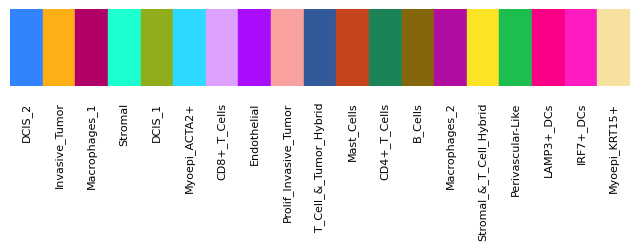

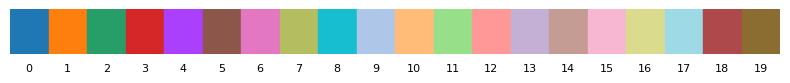

In [7]:
################################### pallete for plotting ###################################
cell_type_list_all = BC.obs['cell_type'].unique().tolist()
# cell_type_color_palette = ["#DEA0FD", "#F3C300", "#875692", "#F38400",
#                            "#A1CAF1", "#BE0032", "#C2B280", "#848482",
#                            "#008856", "#E68FAC", "#0067A5", "#F99379",
#                            "#604E97", "#F6A600", "#B3446C", "#DCD300",
#                            "#882D17", "#8DB600",  "#654522","#E25822"]
cell_type_color_palette = ["#3283FE", "#FEAF16", "#B00068","#1CFFCE", "#90AD1C",
                           "#2ED9FF", "#DEA0FD", "#AA0DFE", "#F8A19F", "#325A9B",
                           "#C4451C", "#1C8356", "#85660D", "#B10DA1", "#FBE426",
                            "#1CBE4F", "#FA0087", "#FC1CBF", "#F7E1A0", "#C075A6"]
cell_type_palette_dict = {cell_type: color for cell_type, color in zip(cell_type_list_all, cell_type_color_palette)}
n_colors = len(cell_type_palette_dict)
fig, ax = plt.subplots(figsize=(8, 1))
for i, (idx, color) in enumerate(cell_type_palette_dict.items()):
    ax.add_patch(plt.Rectangle((i, 0), 1, 1, color=color))
    ax.text(i + 0.5, -0.2, str(idx), ha='center', va='top', fontsize=8, rotation = 90)
ax.set_xlim(0, n_colors)
ax.set_ylim(0, 1)
ax.axis('off')
plt.tight_layout()
plt.show()


niche_all = list(np.arange(20, dtype=np.int64))
niche_default_palette = sc.pl.palettes.default_20
niche_palette_dict = {label: niche_default_palette[label] for label in niche_all}
n_colors = len(niche_palette_dict)
fig, ax = plt.subplots(figsize=(8, 1))
for i, (idx, color) in enumerate(niche_palette_dict.items()):
    ax.add_patch(plt.Rectangle((i, 0), 1, 1, color=color))
    ax.text(i + 0.5, -0.2, str(idx), ha='center', va='top', fontsize=8)
ax.set_xlim(0, n_colors)
ax.set_ylim(0, 1)
ax.axis('off')
plt.tight_layout()
plt.show()


spatial_key = "spatial"
library_id = '151673' # 你的样本的name
BC_filter.uns.setdefault(spatial_key, {}).setdefault(library_id, {})
BC_filter.uns[spatial_key][library_id]["images"] = {"hires": None}
BC_filter.uns[spatial_key][library_id]["scalefactors"] = {"tissue_hires_scalef": 1.,
                                                      "spot_diameter_fullres": 30}


spatial_key = "spatial"
library_id = '151673' # 你的样本的name
BC.uns.setdefault(spatial_key, {}).setdefault(library_id, {})
if "spatial" not in BC.uns:
    BC.uns["spatial"] = {}

if library_id not in BC.uns["spatial"]:
    BC.uns["spatial"][library_id] = {}

BC.uns["spatial"][library_id]["images"] = {"hires": None}
BC.uns[spatial_key][library_id]["scalefactors"] = {"tissue_hires_scalef": 1.,
                                                      "spot_diameter_fullres": 30}
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
from matplotlib.patches import Polygon
from scipy.spatial import ConvexHull

def get_embedding_xy(adata, var_names: str = 'X_umap'):
    """
    优先取 .obsm[var_names]；若不存在，则按常见键顺序回退：
    ['X_umap','umap','X_tsne','tsne','X_pca','pca']。
    返回 (n,2) ndarray（仅前两列）。
    """
    # 先尝试用户请求的键
    if isinstance(var_names, str) and var_names in adata.obsm:
        XY = np.asarray(adata.obsm[var_names])
    else:
        # 常见回退键
        fallbacks = ['X_umap', 'umap', 'X_tsne', 'tsne', 'X_pca', 'pca']
        used = None
        for k in fallbacks:
            if k in adata.obsm:
                used = k
                break
        if used is None:
            raise KeyError(
                f"未找到嵌入坐标：尝试过 { [var_names] + fallbacks }；"
                f"实际可用键为 {list(adata.obsm.keys())}"
            )
        XY = np.asarray(adata.obsm[used])

    if XY.ndim != 2 or XY.shape[1] < 2:
        raise ValueError(f"坐标维度不正确：{XY.shape}（至少需 (n,2)）")
    return XY[:, :2]


# ===== Tool 2: 过滤离群点 =====
def _filter_outliers(P, *, method="auto", q=0.95,
                     dbscan_min_samples=10, eps_quantile=0.90, k_neighbors=8):
    """
    过滤二维点集 P 的离群点：
      - method="auto": 先试 DBSCAN 取最大簇；失败则回退到半径分位数裁剪
      - method="dbscan": 仅用 DBSCAN；不可用时返回原 P
      - method="quantile": 仅用分位数裁剪（保留半径内 q 分位）
    """
    P = np.asarray(P, float)
    if P.shape[0] < 3:
        return P

    def _quantile_trim(P_, q_):
        c = np.median(P_, axis=0)
        d = np.linalg.norm(P_ - c, axis=1)
        r = np.quantile(d, q_)
        return P_[d <= r]

    if method in ("auto", "dbscan"):
        try:
            from sklearn.cluster import DBSCAN
            from sklearn.neighbors import NearestNeighbors
            k = min(max(2, k_neighbors), max(2, P.shape[0] - 1))
            nbrs = NearestNeighbors(n_neighbors=k).fit(P)
            dists, _ = nbrs.kneighbors(P)
            eps = float(np.quantile(dists[:, -1], eps_quantile))
            labels = DBSCAN(eps=eps, min_samples=dbscan_min_samples).fit_predict(P)
            core = labels != -1
            if core.any():
                vals, cnts = np.unique(labels[core], return_counts=True)
                Pf = P[labels == vals[np.argmax(cnts)]]
                if Pf.shape[0] >= 3:
                    return Pf
        except Exception:
            if method == "dbscan":
                return P

    return _quantile_trim(P, q=q)


# ===== Tool 3: 纯 Matplotlib 分层 + 凸包（避免遮挡）=====
def umap_layered_with_hulls(
    adata, color_col, targets, target_colors: dict,
    var_names: str = 'X_umap',
    *,
    # 背景层
    bg_size=5, bg_alpha=0.25, bg_color="#FFFFFF", bg_marker="o",
    # 前景层
    fg_size=20, fg_alpha=0.98, fg_marker="o", outline=True,
    # 凸包
    draw_hull=True, hull_lw=0.9, hull_ls=(0, (6, 4)), q=0.95, dbscan_min_samples=10,
    # 其他
    ax=None, title=None, legend_right=True
):
    """
    分两层绘制 UMAP：
      背景层（小/淡/灰/栅格化）；
      前景层（大/实/彩色，可选边线）；
      可选凸包。
    """
    XY = get_embedding_xy(adata, var_names)
    labels = adata.obs[color_col].astype(str).to_numpy()
    x, y = XY[:, 0], XY[:, 1]

    created = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(5.5, 4.5))
        created = True

    # 背景
    m_bg = ~np.isin(labels, targets)
    ax.scatter(x[m_bg], y[m_bg],
               s=bg_size, c=bg_color, alpha=bg_alpha,
               marker=bg_marker, linewidths=0, zorder=1, rasterized=True)

    # 前景
    for t in targets:
        m = (labels == t)
        if not m.any():
            continue

        # === 边线逻辑 ===
        if isinstance(outline, str):        # outline="#000000" 或 "white"
            ec = outline
            lw = 0.4
        elif outline:                      # True → 黑边
            ec = "k"
            lw = 0.25
        else:                              # False → 无边
            ec = "none"
            lw = 0.0

        ax.scatter(x[m], y[m],
                   s=fg_size, c=target_colors.get(t, "#cccccc"), alpha=fg_alpha,
                   marker=fg_marker, edgecolors=ec, linewidths=lw, zorder=3)

        # 凸包
        if draw_hull:
            P_raw = XY[m]
            P = _filter_outliers(P_raw, method="dbscan", q=q,
                                 dbscan_min_samples=dbscan_min_samples,
                                 eps_quantile=0.98, k_neighbors=8)
            if P.shape[0] >= 3 and np.unique(P, axis=0).shape[0] >= 3:
                hull = ConvexHull(P)
                poly_xy = P[hull.vertices]
                ax.add_patch(Polygon(poly_xy, closed=True, fill=False,
                                     edgecolor="black", linewidth=hull_lw,
                                     linestyle=hull_ls, zorder=4))

    # 图例
    if legend_right:
        handles = [Line2D([0], [0], marker="o", lw=0, color=bg_color,
                          alpha=bg_alpha, markersize=6, label="Background")]
        for t in targets:
            handles.append(Line2D([0], [0], marker="o", lw=0,
                                  color=target_colors.get(t, "#cccccc"),
                                  markersize=8, label=t))
        ax.legend(handles=handles, loc="center left",
                  bbox_to_anchor=(1.02, 0.5), frameon=False)

    ax.set_aspect("equal", adjustable="box")
    ax.axis("off")
    if title:
        ax.set_title(title)
    if created:
        plt.tight_layout(); plt.show()
    return ax



def spatial_layered_with_hulls(
    adata, label_col, targets, target_colors: dict,
    *,
    spatial_key="spatial",
    bg_size=3, bg_alpha=0.25, bg_color="#D3D3D3", bg_marker="o",
    fg_size=8, fg_alpha=0.98, fg_marker="o", outline=True,
    draw_hull=True, hull_lw=1.0, hull_ls=(0, (6, 4)), q=0.98, dbscan_min_samples=10,
    flip_y=True, ax=None, title=None, legend_right=True
):
    # 坐标
    if spatial_key not in adata.obsm:
        raise KeyError(f"adata.obsm['{spatial_key}'] 不存在。")
    XY = np.asarray(adata.obsm[spatial_key])[:, :2]
    x, y = XY[:, 0], XY[:, 1]

    labels = adata.obs[label_col].astype(str).to_numpy()

    created = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(5.5, 4.5))
        created = True

    # 背景层：所有非目标
    # import numpy as np
    m_bg = ~np.isin(labels, targets)
    ax.scatter(x[m_bg], y[m_bg], s=bg_size, c=bg_color, alpha=bg_alpha,
               marker=bg_marker, linewidths=0, zorder=1, rasterized=True)

    # 前景层：逐类叠加 + 凸包
    # from matplotlib.patches import Polygon
    # from matplotlib.lines import Line2D
    # from scipy.spatial import ConvexHull

    for t in targets:
        m = (labels == t)
        if not m.any():
            continue
        ec = "k" if outline else "none"
        lw = 0.25 if outline else 0.0
        ax.scatter(x[m], y[m], s=fg_size, c=target_colors.get(t, "#cccccc"),
                   alpha=fg_alpha, marker=fg_marker, edgecolors=ec, linewidths=lw, zorder=3)

        if draw_hull:
            P_raw = XY[m]
            P = _filter_outliers(P_raw, method="auto", q=q,
                                 dbscan_min_samples=dbscan_min_samples,
                                 eps_quantile=0.90, k_neighbors=8)
            if P.shape[0] >= 3 and np.unique(P, axis=0).shape[0] >= 3:
                hull = ConvexHull(P)
                poly_xy = P[hull.vertices]
                ax.add_patch(Polygon(poly_xy, closed=True, fill=False,
                                     edgecolor="black", linewidth=hull_lw,
                                     linestyle=hull_ls, zorder=4))

    # 轴样式
    ax.set_aspect("equal", adjustable="box")
    if flip_y:
        ax.invert_yaxis()
    ax.axis("off")
    if title:
        ax.set_title(title)

    # 右侧居中图例
    if legend_right:
        handles = [Line2D([0],[0], marker="o", lw=0, color=bg_color,
                          alpha=bg_alpha, markersize=6, label="Background")]
        for t in targets:
            handles.append(Line2D([0],[0], marker="o", lw=0,
                                  color=target_colors.get(t, "#cccccc"),
                                  markersize=8, label=t))
        ax.legend(handles=handles, loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)

    if created:
        plt.tight_layout(); plt.show()
    return ax



######################################################## begin analysis



In [8]:
adata_u_l_umap = ad.AnnData(X=U_l)
adata_u_l_umap.obs = BC_filter.obs
sc.pp.neighbors(adata_u_l_umap)
sc.tl.tsne(adata_u_l_umap)
sc.tl.umap(adata_u_l_umap)
adata_u_l_umap.obs = BC_filter.obs

sc.pp.pca(BC)
sc.pp.neighbors(BC)
sc.tl.umap(BC)
sc.tl.tsne(BC)

D:\Users\lihs\anaconda3\envs\CommuNiche_test\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
D:\Users\lihs\anaconda3\envs\CommuNiche_test\lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


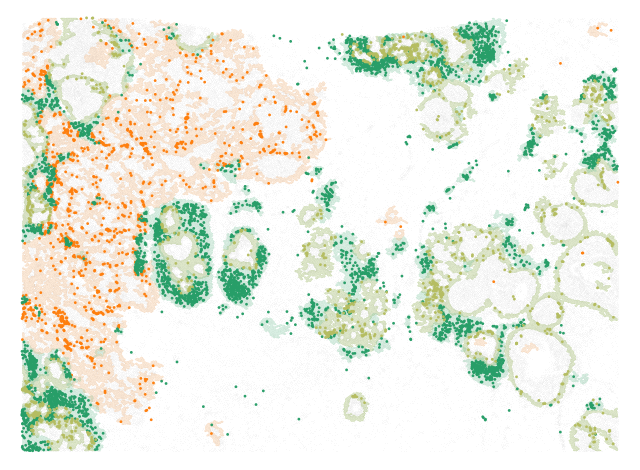

Axes(0.0230769,0.0900027;0.953846x0.819995)


In [9]:
masked_label = BC_filter.obs['cell_type'].astype(str).copy()
masked_label[BC_filter.obs['cell_type'] != 'CD8+_T_Cells'] = 'Other'
BC_filter.obs['cell_type_masked'] = masked_label.astype('category')
color_map_left = {"CD8+_T_Cells": cell_type_palette_dict.get("CD8+_T_Cells", "#1f77b4")}

# ================== 右图：adata_u_l_umap（高亮 Astro Niche 5/6） ==================
# （你已有 adata_u_l_umap & niche_palette_dict）
is_astro = adata_u_l_umap.obs["cell_type"].astype(str).eq("CD8+_T_Cells")
niche_id = adata_u_l_umap.obs['CD_clustering_9_vis']
lab = pd.Series("Other", index=adata_u_l_umap.obs.index, dtype="object")
lab[is_astro & niche_id.eq(1)] = "CD8+ Niche 1"
lab[is_astro & niche_id.eq(2)] = "CD8+ Niche 2"
lab[is_astro & niche_id.eq(7)] = "CD8+ Niche 7"
adata_u_l_umap.obs["Commu_CD8_masked"] = lab.astype('category')

adata_u_l_umap.obs_names = adata_u_l_umap.obs_names.astype(str)


color_map_right = {
    "CD8+ Niche 1": niche_palette_dict.get(1, "#6F00FF"),
    "CD8+ Niche 2": niche_palette_dict.get(2, "#00FF6F"),
    "CD8+ Niche 7": niche_palette_dict.get(7, "#00FF6F")
}

BC_filter.obs['Commu_CD8_masked_sp'] = adata_u_l_umap.obs['Commu_CD8_masked']



BC.obs['CD_clustering_5'] = BC_filter.obs['CD_clustering_5']
BC.obs['CD_clustering_9'] = BC_filter.obs['CD_clustering_9']
BC.obs['CD_clustering_13'] = BC_filter.obs['CD_clustering_13']
BC.obs['CD_clustering_17'] = BC_filter.obs['CD_clustering_17']
BC.obs['CD_clustering_5_vis'] = BC_filter.obs['CD_clustering_5_vis']
BC.obs['CD_clustering_9_vis'] = BC_filter.obs['CD_clustering_9_vis']
BC.obs['CD_clustering_13_vis'] = BC_filter.obs['CD_clustering_13_vis']
BC.obs['CD_clustering_17_vis'] = BC_filter.obs['CD_clustering_17_vis']

BC.obs['cell_type_masked'] = list(BC_filter.obs['cell_type_masked'].astype('category'))
BC.obs['Commu_CD8_masked'] = BC_filter.obs['Commu_CD8_masked'].astype('category')
BC.obs['Commu_CD8_masked_sp'] = BC_filter.obs['Commu_CD8_masked_sp'].astype('category')

def plot_multiple_niche_regions_with_marked_points(
    adata,
    niche_labels,
    domain_index,
    niche_color_dict,
    *,
    spatial_key="spatial",

    # ===== region reconstruction =====
    grid_size=220,
    min_count_per_bin=3,
    min_region_bins=25,
    dilation_iters=1,
    closing_iters=1,
    region_smooth_sigma=0.5,
    region_threshold=0.18,

    # ===== region visualization =====
    alpha_fill=0.30,
    contour_linewidth=1.2,
    contour_alpha=0.95,

    # ===== global background =====
    draw_background=True,
    background_point_size=0.6,
    background_color="#D9D9D9",
    background_alpha=0.18,

    # ===== marked points layer (from your spatial_layered_with_hulls logic) =====
    mark_label_col=None,
    mark_targets=None,
    mark_target_colors=None,
    mark_bg_size=2,
    mark_bg_alpha=0.0,          # 默认不额外画“标记逻辑里的背景”，避免和全局背景冲突
    mark_bg_color="#D3D3D3",
    mark_bg_marker="o",
    mark_fg_size=8,
    mark_fg_alpha=0.98,
    mark_fg_marker="o",
    mark_outline=False,
    mark_outline_color="k",
    mark_outline_lw=0.25,
    draw_hull=False,
    hull_lw=1.0,
    hull_ls=(0, (6, 4)),
    hull_color="black",
    q=0.98,
    dbscan_min_samples=10,

    # ===== canvas =====
    figsize=(6.5, 5.5),
    flip_y_like_scanpy=True,
    title=None,
    legend_right=False,
    save_path=None,
):
    """
    Plot multiple reconstructed niche connected regions on one panel,
    and overlay selected marked points on top.

    Main idea:
    1) reconstruct each niche into a connected soft region
    2) render all niches on one spatial map
    3) overlay selected points from mark_label_col / mark_targets
    """

    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.lines import Line2D
    from matplotlib.patches import Polygon
    from scipy import ndimage as ndi
    from scipy.spatial import ConvexHull
    from sklearn.cluster import DBSCAN
    from sklearn.neighbors import NearestNeighbors

    # -------------------------
    # helpers
    # -------------------------
    def _get_target_color(t):
        if mark_target_colors is None:
            return "#cccccc"
        return mark_target_colors.get(t, "#cccccc")

    def _filter_outliers(P_raw, method="auto", q=0.98,
                         dbscan_min_samples=10,
                         eps_quantile=0.90, k_neighbors=8):
        """
        Simple robust outlier filter for hull drawing.
        """
        P_raw = np.asarray(P_raw)
        if P_raw.shape[0] < 5:
            return P_raw

        # distance-to-center trimming
        center = np.median(P_raw, axis=0)
        d = np.sqrt(((P_raw - center) ** 2).sum(axis=1))
        thr = np.quantile(d, q)
        P1 = P_raw[d <= thr]

        if P1.shape[0] < 5:
            return P_raw

        # DBSCAN refine
        try:
            nn = NearestNeighbors(n_neighbors=min(k_neighbors, max(2, len(P1)-1)))
            nn.fit(P1)
            dist, _ = nn.kneighbors(P1)
            kth = dist[:, -1]
            eps = np.quantile(kth, eps_quantile)

            db = DBSCAN(eps=eps, min_samples=dbscan_min_samples)
            lab = db.fit_predict(P1)

            valid = lab >= 0
            if valid.sum() == 0:
                return P1

            # keep largest cluster
            uniq, cnt = np.unique(lab[valid], return_counts=True)
            keep_lab = uniq[np.argmax(cnt)]
            P2 = P1[lab == keep_lab]

            if P2.shape[0] >= 3:
                return P2
            return P1
        except Exception:
            return P1

    def build_soft_region(mask, x, y, x_min, x_max, y_min, y_max):
        x_in = x[mask]
        y_in = y[mask]

        if x_in.size == 0:
            return None

        H, xedges, yedges = np.histogram2d(
            x_in,
            y_in,
            bins=grid_size,
            range=[[x_min, x_max], [y_min, y_max]]
        )
        H = H.T

        occ = H >= min_count_per_bin

        if dilation_iters > 0:
            occ = ndi.binary_dilation(occ, iterations=dilation_iters)

        if closing_iters > 0:
            occ = ndi.binary_closing(occ, iterations=closing_iters)

        structure = np.ones((3, 3), dtype=int)
        labeled, n_regions = ndi.label(occ, structure=structure)

        keep = np.zeros_like(occ, dtype=bool)
        if n_regions > 0:
            region_sizes = np.bincount(labeled.ravel())
            for rid in range(1, len(region_sizes)):
                if region_sizes[rid] >= min_region_bins:
                    keep |= (labeled == rid)

        if not keep.any():
            return None

        soft = ndi.gaussian_filter(keep.astype(float), sigma=region_smooth_sigma)
        if np.nanmax(soft) < region_threshold:
            return None

        xx = 0.5 * (xedges[:-1] + xedges[1:])
        yy = 0.5 * (yedges[:-1] + yedges[1:])
        XX, YY = np.meshgrid(xx, yy)

        return {
            "soft": soft,
            "XX": XX,
            "YY": YY,
        }

    # -------------------------
    # data
    # -------------------------
    if spatial_key not in adata.obsm:
        raise KeyError(f"adata.obsm['{spatial_key}'] does not exist.")

    XY = np.asarray(adata.obsm[spatial_key])[:, :2]
    x = XY[:, 0]
    y = XY[:, 1]
    dom = adata.obs[domain_index].astype(str).values

    x_min, x_max = x.min(), x.max()
    y_min, y_max = y.min(), y.max()

    # -------------------------
    # figure
    # -------------------------
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_aspect("equal")
    ax.axis("off")

    pad = 0.02
    xr = x_max - x_min
    yr = y_max - y_min
    ax.set_xlim(x_min - pad * xr, x_max + pad * xr)
    ax.set_ylim(y_min - pad * yr, y_max + pad * yr)

    if flip_y_like_scanpy:
        ax.invert_yaxis()

    # -------------------------
    # background
    # -------------------------
    if draw_background:
        ax.scatter(
            x, y,
            s=background_point_size,
            c=background_color,
            linewidths=0,
            alpha=background_alpha,
            rasterized=True,
            zorder=1
        )

    # -------------------------
    # draw multiple niche regions
    # -------------------------
    for i, niche_label in enumerate(niche_labels, start=1):
        mask = dom == str(niche_label)
        region = build_soft_region(mask, x, y, x_min, x_max, y_min, y_max)

        if region is None:
            print(f"[skip] niche {niche_label!r}: no valid connected region")
            continue

        color = niche_color_dict.get(niche_label, "#cccccc")
        soft = region["soft"]
        XX = region["XX"]
        YY = region["YY"]

        # filled
        ax.contourf(
            XX,
            YY,
            soft,
            levels=[region_threshold, float(np.nanmax(soft)) + 1e-12],
            colors=[color],
            alpha=alpha_fill,
            antialiased=True,
            zorder=2 + i
        )

        # outline
        ax.contour(
            XX,
            YY,
            soft,
            levels=[region_threshold],
            colors=[color],
            linewidths=contour_linewidth,
            alpha=contour_alpha,
            zorder=20 + i
        )

    # -------------------------
    # overlay marked points
    # -------------------------
    legend_handles = []

    if mark_label_col is not None and mark_targets is not None:
        labels = adata.obs[mark_label_col].astype(str).to_numpy()

        # optional background for non-targets within mark layer
        if mark_bg_alpha > 0:
            m_bg = ~np.isin(labels, mark_targets)
            ax.scatter(
                x[m_bg], y[m_bg],
                s=mark_bg_size,
                c=mark_bg_color,
                alpha=mark_bg_alpha,
                marker=mark_bg_marker,
                linewidths=0,
                zorder=50,
                rasterized=True
            )

        # target points + optional hull
        for t in mark_targets:
            m = labels == t
            if not m.any():
                continue

            ec = mark_outline_color if mark_outline else "none"
            lw = mark_outline_lw if mark_outline else 0.0

            ax.scatter(
                x[m], y[m],
                s=mark_fg_size,
                c=_get_target_color(t),
                alpha=mark_fg_alpha,
                marker=mark_fg_marker,
                edgecolors=ec,
                linewidths=lw,
                zorder=60
            )

            if draw_hull:
                P_raw = XY[m]
                P = _filter_outliers(
                    P_raw,
                    method="auto",
                    q=q,
                    dbscan_min_samples=dbscan_min_samples,
                    eps_quantile=0.90,
                    k_neighbors=8
                )
                if P.shape[0] >= 3 and np.unique(P, axis=0).shape[0] >= 3:
                    hull = ConvexHull(P)
                    poly_xy = P[hull.vertices]
                    ax.add_patch(
                        Polygon(
                            poly_xy,
                            closed=True,
                            fill=False,
                            edgecolor=hull_color,
                            linewidth=hull_lw,
                            linestyle=hull_ls,
                            zorder=70
                        )
                    )

            if legend_right:
                legend_handles.append(
                    Line2D(
                        [0], [0],
                        marker="o",
                        lw=0,
                        color=_get_target_color(t),
                        markersize=6,
                        label=t
                    )
                )

    # -------------------------
    # legend / title
    # -------------------------
    if title is not None:
        ax.set_title(title)

    if legend_right and len(legend_handles) > 0:
        ax.legend(
            handles=legend_handles,
            loc="center left",
            bbox_to_anchor=(1.02, 0.5),
            frameon=False
        )

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()
    return ax


niche_fill_colors = {
    1 : "#F2B37A",  # 浅橙（来自 #ff7f0e）
    2 : "#7FC8A0",  # 浅绿（来自 #279e68）
    7 : "#8FAF4F",  # 浅黄绿（来自 #b5bd61）
}
ax_region = plot_multiple_niche_regions_with_marked_points(
    adata=BC_filter,
    niche_labels=[7,2, 1],
    domain_index="CD_clustering_9_vis",   # 这里改成你真正的 niche 列名
    niche_color_dict= niche_fill_colors,

    # region
    grid_size=800,
    min_count_per_bin=1,
    min_region_bins=100,
    dilation_iters=1,
    closing_iters=1,
    region_smooth_sigma=0.5,
    region_threshold=0.18,

    # region style
    alpha_fill=0.3,
    contour_linewidth=0.1,

    # global background
    draw_background=True,
    background_point_size=0.4,
    background_color="#DCDCDC",
    background_alpha=0.15,

    # marked points
    mark_label_col="Commu_CD8_masked_sp",
    mark_targets=["CD8+ Niche 1", "CD8+ Niche 2", "CD8+ Niche 7"],
    mark_target_colors=color_map_right,
    mark_bg_alpha=0.0,
    mark_fg_size=4,
    mark_fg_alpha=0.98,
    mark_fg_marker="o",
    mark_outline=False,
    draw_hull=False,

    flip_y_like_scanpy=True,
    # title="Marked points on multi-niche connected regions",
    # legend_right=True,
    save_path=None,
)
print(ax_region)




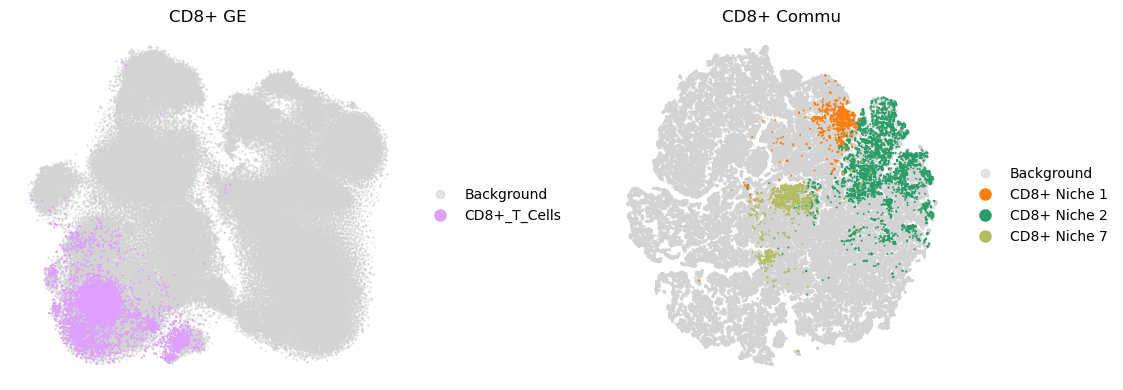

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# 1) 你已有的 UMAP 左图
umap_layered_with_hulls(
    BC, color_col="cell_type_masked", var_names = 'X_tsne', 
    targets=["CD8+_T_Cells"], target_colors=color_map_left,
    bg_size=2, bg_alpha=0.6, bg_color = "#D3D3D3", 
    fg_size=2, fg_alpha=0.98,
    outline=False, draw_hull=False, hull_lw=0.9, q=0.98,
    ax=ax1, title="CD8+ GE"
)

# 2) 你已有的 UMAP 右图
umap_layered_with_hulls(
    adata_u_l_umap, color_col="Commu_CD8_masked", var_names = 'X_tsne',
    targets=["CD8+ Niche 1", "CD8+ Niche 2", 'CD8+ Niche 7'], target_colors=color_map_right,
    bg_size=2, bg_alpha=0.6, bg_color = "#D3D3D3",
    fg_size=2, fg_alpha=0.98,
    outline=False, draw_hull=False, hull_lw=1.0, q=1.0,
    ax=ax2, title="CD8+ Commu"
)



plt.tight_layout()
plt.show()

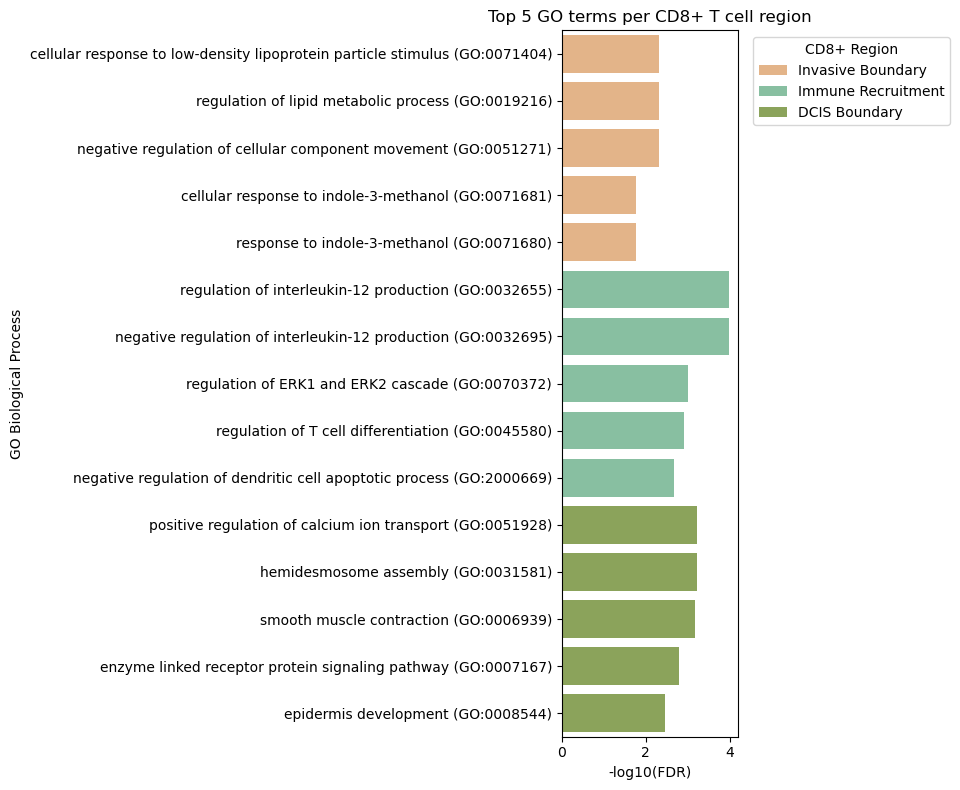

In [13]:
### Marker genes and GO enrichment analysis
adata_tmp = BC[BC.obs["Commu_CD8_masked_sp"] != 'Other'].copy()   # 原对象不改动
# group_col    = "Commu_CD8_masked_sp"        # 分组列（categorical）
# target_group = "CD8+_T_Cells"           # 目标组
# use_raw = False                  # 若表达在 .raw，改为 True
# layer   = None                   # 若在某个 layer（如 "log1p"），填上；否则 None
min_cells_per_gene = 10          # 过滤仅在很少细胞表达的基因
method  = "t-test" 
adata_tmp.obs['Commu_CD8_masked_sp'] = adata_tmp.obs['Commu_CD8_masked_sp'].astype('category')

sc.tl.rank_genes_groups(
    adata_tmp,
    groupby='Commu_CD8_masked_sp',  # 分组列
    method='wilcoxon',                # 或者 'wilcoxon', 'logreg'
    pts=True                        # 计算每个基因在组内的表达比例
)

result = adata_tmp.uns['rank_genes_groups']
groups = result['names'].dtype.names  # 会是三组

# 设置 log fold change 阈值
logfc_threshold = 0.25# 你可以改成 0.25 等

# 创建空 DataFrame 保存每组 marker
marker_genes_dict = {}

for group in groups:
    # 提取每组结果
    names = result['names'][group]
    pvals_adj = result['pvals_adj'][group]
    logfc = result['logfoldchanges'][group]
    
    # 转成 DataFrame
    df_group = pd.DataFrame({
        'gene': names,
        'logfc': logfc,
        'pvals_adj': pvals_adj
    })
    
    # 筛选条件
    df_filtered = df_group[(df_group['pvals_adj'] < 0.05) & (df_group['logfc'] > logfc_threshold)]
    
    marker_genes_dict[group] = df_filtered

# 查看某一组
marker_genes_dict['CD8+ Niche 2']

import gseapy as gp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

invasive_boundary_1_genes = list(marker_genes_dict['CD8+ Niche 1']['gene'])
immune_recuite_2_genes = list(marker_genes_dict['CD8+ Niche 2']['gene'])
DCIS_boudanry_7_genes = list(marker_genes_dict['CD8+ Niche 7']['gene'])

gene_sets = {
    "Invasive Boundary": invasive_boundary_1_genes,
    "Immune Recruitment": immune_recuite_2_genes,
    "DCIS Boundary": DCIS_boudanry_7_genes
}


go_results = []

for group_name, genes in gene_sets.items():
    enr = gp.enrichr(
        gene_list=genes,
        gene_sets=['GO_Biological_Process_2021'],
        organism='hs',
        cutoff=0.05
    )
    # Top5 GO term
    top5 = enr.results.sort_values('Adjusted P-value').head(5).copy()
    top5['-log10(FDR)'] = -np.log10(top5['Adjusted P-value'])
    top5['Group'] = group_name
    go_results.append(top5[['Term','-log10(FDR)','Group']])

# 合并
all_go = pd.concat(go_results, ignore_index=True)

# -------------------------------
# 3. 条形图可视化
# -------------------------------
niche_fill_colors = {
    "Invasive Boundary": "#F2B37A",   # 浅橙
    "Immune Recruitment": "#7FC8A0",  # 浅绿
    "DCIS Boundary": "#8FAF4F",       # 浅黄绿
}

# 绘制条形图
plt.figure(figsize=(10,8))
sns.barplot(
    data=all_go,
    y='Term',
    x='-log10(FDR)',
    hue='Group',
    palette=niche_fill_colors  # 使用自定义颜色
)
plt.xlabel('-log10(FDR)')
plt.ylabel('GO Biological Process')
plt.title('Top 5 GO terms per CD8+ T cell region')
plt.legend(title='CD8+ Region', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Correlation with the communication programs

Correlation with communication programs for the niche-dependent CD8+ states

Calculating the enrichment of each cluster (rank_idx) in group (CD_clustering_9_vis)...


C:\Users\lihs\CommuNiche\CommuNiche\utils.py:2890: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_count = obs.groupby([id_key, val_key]).size().unstack().fillna(0)
C:\Users\lihs\CommuNiche\CommuNiche\utils.py:228: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  pval_str = pval.applymap(_convert_pval_to_asterisks)


AttributeError: 'NoneType' object has no attribute 'write'

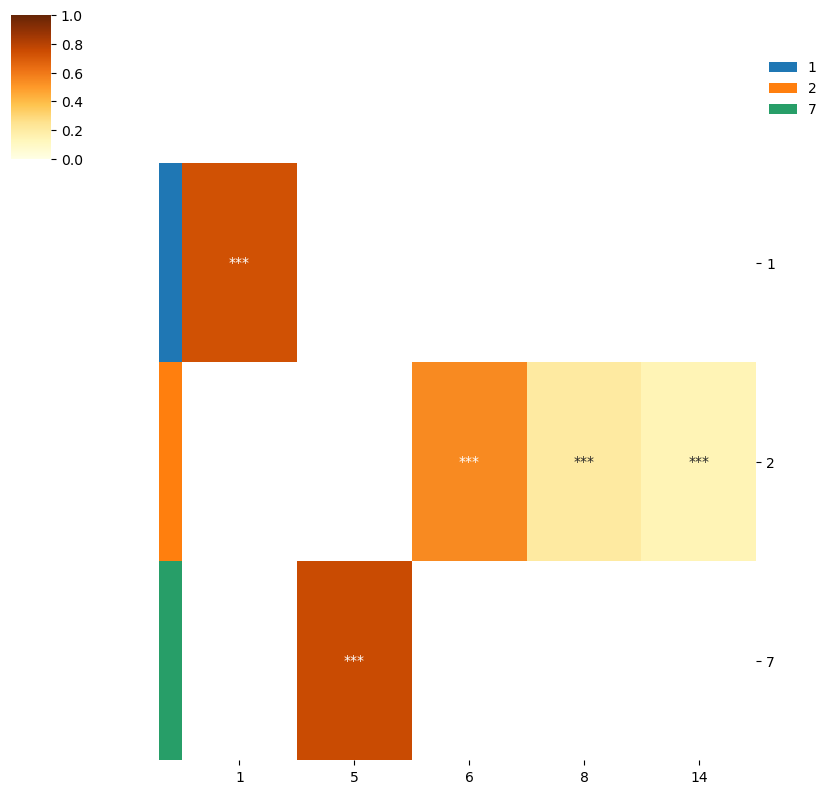

In [15]:
mask_astro  = BC_filter.obs['cell_type'].astype(str).eq('CD8+_T_Cells')
mask_niche  = BC_filter.obs['CD_clustering_9'].isin(['Niche 1', 'Niche 2', 'Niche 7'])
mask = mask_astro & mask_niche
ms_filter_small = BC_filter[mask.values].copy()

ref = cell_names
query = ms_filter_small.obs_names.tolist()
idx = (lambda m={v:i for i,v in enumerate(ref)}: [m.get(s) for s in query])()
U_small = U_l[idx,:]

row_order_select_rank = list([1, 2, 7])
col_order_select_rank = list([1, 5, 6, 8, 14])

df_normalized, pval, pval_adj, significant_ranks = CN.utils.select_ranks(ms_filter_small, U = U_small, niche_idx = 'CD_clustering_9_vis', 
                                                                plot_fig = True, save = True, row_order = row_order_select_rank, 
                                                                col_order = col_order_select_rank,
                                                                save_fig = None)



## Obtaining the neighboring cell types and LR

C:\Users\lihs\AppData\Local\Temp\ipykernel_19128\1132514300.py:30: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  BC_filter.obs['cell_type_micro'].loc[CD8_1_index] = 'CD8 niche 1'
C:\Users\lihs\AppData\Local\Temp\ipykernel_19128\1132514300.py

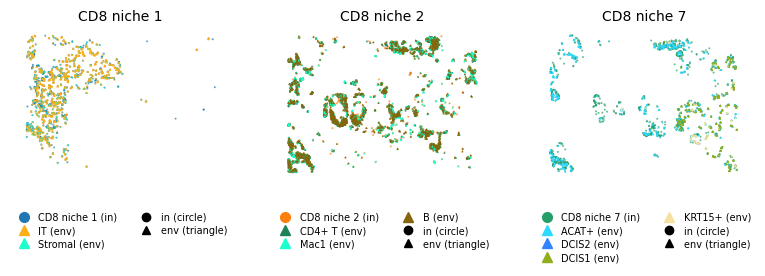

In [17]:
def select_cell_micro(adata, domain_index, special_spatial_domain, k = 10):
   ad_matrix, _, _, _, _, _ =  CN.utils.cal_K_neighboorhood(adata.obsm['spatial'], k=k, cell_types=None)
   
   dom_col = adata.obs[domain_index].astype(str).values
   domain_mask = (dom_col == str(special_spatial_domain))
   rows = np.flatnonzero(domain_mask)
   neighbor_cols = ad_matrix[rows, :].nonzero()[1] 
   
   n = adata.n_obs
   neighbor_mask = np.zeros(n, dtype=bool)
   neighbor_mask[neighbor_cols] = True

   selected_mask = domain_mask.copy()
   selected_mask[neighbor_cols] = True
   
   pos = np.flatnonzero(selected_mask)         # 保持 adata.obs 原顺序
   idx = adata.obs_names[pos]

   df = pd.DataFrame(index=idx)
   df["in_domain"] = domain_mask[pos]
   df["is_neighbor_only"] = neighbor_mask[pos] & (~domain_mask[pos])

   return idx, df
   

CD8_1_index = adata_u_l_umap.obs.query("Commu_CD8_masked in 'CD8+ Niche 1'").index.tolist()
CD8_2_index = adata_u_l_umap.obs.query("Commu_CD8_masked in 'CD8+ Niche 2'").index.tolist()
CD8_7_index = adata_u_l_umap.obs.query("Commu_CD8_masked in 'CD8+ Niche 7'").index.tolist()
BC_filter.obs['cell_type_micro'] = BC_filter.obs['cell_type'].astype('str')
BC_filter.obs['cell_type_micro'].loc[CD8_1_index] = 'CD8 niche 1'
BC_filter.obs['cell_type_micro'].loc[CD8_2_index] = 'CD8 niche 2'
BC_filter.obs['cell_type_micro'].loc[CD8_7_index] = 'CD8 niche 7'


_, df_mic0 = select_cell_micro(BC_filter, domain_index = 'cell_type_micro', special_spatial_domain = 'CD8 niche 1', k = 10)
flags = df_mic0.reindex(BC_filter.obs_names).fillna(False)
BC_filter.obs["in_CD8_niche_1"]        = flags["in_domain"].astype(bool).to_numpy()
BC_filter.obs["is_neighbor_CD8_niche_1"] = flags["is_neighbor_only"].astype(bool).to_numpy()
BC_filter.obs["in_CD8_niche_1_or_neighbor"] = BC_filter.obs["in_CD8_niche_1"] | BC_filter.obs["is_neighbor_CD8_niche_1"]



_, df_mic1 = select_cell_micro(BC_filter, domain_index = 'cell_type_micro', special_spatial_domain = 'CD8 niche 2', k = 10)
flags = df_mic1.reindex(BC_filter.obs_names).fillna(False)
BC_filter.obs["in_CD8_niche_2"]        = flags["in_domain"].astype(bool).to_numpy()
BC_filter.obs["is_neighbor_CD8_niche_2"] = flags["is_neighbor_only"].astype(bool).to_numpy()
BC_filter.obs["in_CD8_niche_2_or_neighbor"] = BC_filter.obs["in_CD8_niche_2"] | BC_filter.obs["is_neighbor_CD8_niche_2"]



_, df_mic2 = select_cell_micro(BC_filter, domain_index = 'cell_type_micro', special_spatial_domain = 'CD8 niche 7', k = 10)
flags = df_mic2.reindex(BC_filter.obs_names).fillna(False)
BC_filter.obs["in_CD8_niche_7"]        = flags["in_domain"].astype(bool).to_numpy()
BC_filter.obs["is_neighbor_CD8_niche_7"] = flags["is_neighbor_only"].astype(bool).to_numpy()
BC_filter.obs["in_CD8_niche_7_or_neighbor"] = BC_filter.obs["in_CD8_niche_7"] | BC_filter.obs["is_neighbor_CD8_niche_7"]



def get_scanpy_spatial_limits(adata, spot_size=1e-9):
    import matplotlib.pyplot as plt
    import scanpy as sc
    fig = plt.figure()
    ax = fig.add_subplot(111)
    sc.pl.spatial(adata, color=None, spot_size=spot_size, frameon=False, ax=ax, show=False)
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    y_inv = ax.yaxis_inverted()  # True 表示 scanpy 的Y轴是倒置的
    plt.close(fig)
    return xlim, ylim, y_inv

def apply_axes_like_scanpy(ax, xlim, ylim, y_inv):
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    if y_inv and not ax.yaxis_inverted():
        ax.invert_yaxis()
        

# ===== 颜色定义 =====
C_GREY     = "#FFFFFF"
C_CD8    = "#DEA0FD"
C_CD8_1  = "#1f77b4"
C_CD8_2  = "#ff7f0e"
C_CD8_7 = "#279e68"
 
C_CD4     = "#1C8356"
C_Mac1 = '#1CFFCE'
C_B = '#85660D'

C_DCIS1 = '#90AD1C'
C_DCIS2 = '#3283FE'
C_KRT15 = '#F7E1A0'
C_ATAC2 = '#2ED9FF'
C_T_tumor_hy = '#325A9B'

C_IT = '#FEAF16'
C_Stromal = '#1CFFCE'



# S_BG, S_HI = 2, 6
# ALPHA_BG, ALPHA_HI = 0.40, 0.95
# FLIP_Y_LIKE_SCANPY = True

# ===== 列名 =====
IN_COL_1   = "in_CD8_niche_1"
ANY_COL_1  = "in_CD8_niche_1_or_neighbor"
IN_COL_2   = "in_CD8_niche_2"
ANY_COL_2  = "in_CD8_niche_2_or_neighbor"
IN_COL_7   = "in_CD8_niche_7"
ANY_COL_7  = "in_CD8_niche_7_or_neighbor"



TYPE_COL   = "cell_type_micro"

# ===== 掩码 =====
types = BC_filter.obs[TYPE_COL].astype(str).to_numpy()

m_any1 = BC_filter.obs[ANY_COL_1].astype(bool).to_numpy()
m_in1  = BC_filter.obs[IN_COL_1].astype(bool).to_numpy()
m_any2 = BC_filter.obs[ANY_COL_2].astype(bool).to_numpy()
m_in2  = BC_filter.obs[IN_COL_2].astype(bool).to_numpy()
m_any7 = BC_filter.obs[ANY_COL_7].astype(bool).to_numpy()
m_in7  = BC_filter.obs[IN_COL_7].astype(bool).to_numpy()

# =============================================================
# Panel A —— CD8 niche 2 (in) + 邻域 CD8 niche 2 (env)
# =============================================================
lab2_in  = pd.Series("Other", index=BC_filter.obs.index, dtype="object")
lab2_env = pd.Series("Other", index=BC_filter.obs.index, dtype="object")

m_n2 = (types == "CD8 niche 2")
m_CD4_2 = (types == "CD4+_T_Cells")
m_Mac1_2 = (types == 'Macrophages_1')
m_B_2 = (types == 'B_Cells')


lab2_in = pd.Series("Other", index=BC_filter.obs.index, dtype="object")
lab2_in[m_n2 & m_any2 &  m_in2] = "CD8 niche 2 (in)"
BC_filter.obs["_n2_in"] = pd.Categorical(
    lab2_in, categories=["Other", "CD8 niche 2 (in)"]
)
# ====== env 分两列：_n0_CD4_env & _n0_Stromal_env ======
lab2_CD4_env = pd.Series("Other", index=BC_filter.obs.index, dtype="object")
lab2_CD4_env[m_CD4_2 & m_any2 & ~m_in2] = "CD4+ T (env)"
BC_filter.obs["_n2_CD4_env"] = pd.Categorical(
    lab2_CD4_env, categories=["Other", "CD4+ T (env)"]
)

lab2_Mac1_env = pd.Series("Other", index=BC_filter.obs.index, dtype="object")
lab2_Mac1_env[m_Mac1_2 & m_any2 & ~m_in2] = "Mac1 (env)"
BC_filter.obs["_n2_Mac1_env"] = pd.Categorical(
    lab2_Mac1_env, categories=["Other", "Mac1 (env)"]
)


lab2_B_env = pd.Series("Other", index=BC_filter.obs.index, dtype="object")
lab2_B_env[m_B_2 & m_any2 & ~m_in2] = "B (env)"
BC_filter.obs["_n2_B_env"] = pd.Categorical(
    lab2_B_env, categories=["Other", "B (env)"]
)


targets2_in           = ["CD8 niche 2 (in)"]
targets2_CD4_env      = ["CD4+ T (env)"]
targets2_Mac1_env  =  ["Mac1 (env)"]
targets2_B_env  =  ["B (env)"]

colors2_in            = {"CD8 niche 2 (in)": C_CD8_2}
colors2_CD4_env       = {"CD4+ T (env)"    : C_CD4}
colors2_Mac1_env   = {"Mac1 (env)"   : C_Mac1}
colors2_B_env   = {"B (env)"   : C_B}

# =============================================================
# Panel B —— CD8 niche 1 (in) + 邻域 CD8 niche 1 (env)
# =============================================================
lab1_in  = pd.Series("Other", index=BC_filter.obs.index, dtype="object")

m_n1      = (types == "CD8 niche 1")
m_IT_1 = (types == "Invasive_Tumor")
m_Stromal_1   = (types == "Stromal")

# niche 1 (in)
lab1_in[m_n1 & m_any1 &  m_in1] = "CD8 niche 1 (in)"
BC_filter.obs["_n1_in"] = pd.Categorical(
    lab1_in, categories=["Other", "CD8 niche 1 (in)"]
)

lab1_IT_env = pd.Series("Other", index=BC_filter.obs.index, dtype="object")
lab1_Stromal_env   = pd.Series("Other", index=BC_filter.obs.index, dtype="object")

lab1_IT_env[m_IT_1 & m_any1 & ~m_in1] = "IT (env)"
lab1_Stromal_env[m_Stromal_1  & m_any1 & ~m_in1]   = "Stromal (env)"

BC_filter.obs["_n1_IT_env"] = pd.Categorical(
    lab1_IT_env, categories=["Other", "IT (env)"]
)
BC_filter.obs["_n1_Stromal_env"] = pd.Categorical(
    lab1_Stromal_env, categories=["Other", "Stromal (env)"]
)

targets1_in          = ["CD8 niche 1 (in)"]
targets1_IT_env   = ["IT (env)"]
targets1_Stromal_env     = ["Stromal (env)"]

colors1_in           = {"CD8 niche 1 (in)"   : C_CD8_1}
colors1_IT_env    = {"IT (env)"        : C_IT}
colors1_Stromal_env      = {"Stromal (env)": C_Stromal}

# =============================================================
# Panel B —— CD8 niche 7 (in) + 邻域 CD8 niche 7 (env)
# =============================================================

lab7_in  = pd.Series("Other", index=BC_filter.obs.index, dtype="object")
m_n7     = (types == "CD8 niche 7")
m_ACAT_7   = (types == "Myoepi_ACTA2+")
m_DC2_7 = (types == "DCIS_2")
m_DC1_7   = (types == "DCIS_1")
m_KRT_7 = (types == "Myoepi_KRT15+")



lab7_in[m_n7 & m_any7 &  m_in7] = "CD8 niche 7 (in)"
BC_filter.obs["_n7_in"] = pd.Categorical(
    lab7_in, categories=["Other", "CD8 niche 7 (in)"]
)

lab7_ACAT_env  = pd.Series("Other", index=BC_filter.obs.index, dtype="object")
lab7_DC2_env = pd.Series("Other", index=BC_filter.obs.index, dtype="object")
lab7_DC1_env  = pd.Series("Other", index=BC_filter.obs.index, dtype="object")
lab7_KRT_env = pd.Series("Other", index=BC_filter.obs.index, dtype="object")

lab7_ACAT_env [m_ACAT_7  & m_any7 & ~m_in7] = "ACAT+ (env)"
lab7_DC2_env[m_DC2_7  & m_any7 & ~m_in7] = "DCIS2 (env)"
lab7_DC1_env [m_DC1_7  & m_any7 & ~m_in7] = "DCIS1 (env)"
lab7_KRT_env[m_KRT_7  & m_any7 & ~m_in7] = "KRT15+ (env)"


BC_filter.obs["_n7_ACAT_env"] = pd.Categorical(
    lab7_ACAT_env, categories=["Other", "ACAT+ (env)"]
)
BC_filter.obs["_n7_DC2_env"] = pd.Categorical(
    lab7_DC2_env, categories=["Other", "DCIS2  (env)"]
)

BC_filter.obs["_n7_DC1_env"] = pd.Categorical(
    lab7_DC1_env, categories=["Other", "DCIS1 (env)"]
)
BC_filter.obs["_n7_KRT_env"] = pd.Categorical(
    lab7_KRT_env, categories=["Other", "KRT15+ (env)"]
)



targets7_in         = ["CD8 niche 7 (in)"]
targets7_ACAT_env     = ["ACAT+ (env)"]
targets7_DC2_env    = ["DCIS2 (env)"]
targets7_DC1_env     = ["DCIS1 (env)"]
targets7_KRT_env    = ["KRT15+ (env)"]


colors7_in          = {"CD8 niche 7 (in)"     : C_CD8_7}
colors7_ACAT_env      = {"ACAT+ (env)" : C_ATAC2}
colors7_DC2_env     = {"DCIS2 (env)" : C_DCIS2}
colors7_DC1_env      = {"DCIS1 (env)" : C_DCIS1}
colors7_KRT_env     = {"KRT15+ (env)" : C_KRT15}

# =============================================================
# 绘图
# =============================================================
S_BG, S_HI = 0.1, 2
ALPHA_BG, ALPHA_HI = 0.40, 0.7
FLIP_Y_LIKE_SCANPY = True

fig, (ax5, ax6, ax7) = plt.subplots(1, 3, figsize=(8, 4))

# --- Panel A: CD8 niche 1 ---
spatial_layered_with_hulls(
    BC_filter, label_col="_n1_in",
    targets=targets1_in, target_colors=colors1_in,
    spatial_key="spatial",
    bg_size=S_BG, bg_alpha=ALPHA_BG, bg_color=C_GREY,
    fg_size=2, fg_alpha=0.7, fg_marker="o",
    outline=False, draw_hull=False,
    flip_y=FLIP_Y_LIKE_SCANPY,
    ax=ax5, title="CD8 niche 1",
    legend_right=False
)
# env: CD4+ 与 Stromal 分开叠加（不重复背景）
spatial_layered_with_hulls(
    BC_filter, label_col="_n1_IT_env",
    targets=targets1_IT_env, target_colors=colors1_IT_env,
    spatial_key="spatial",
    bg_size=0, bg_alpha=0.0, bg_color=C_GREY,
    fg_size=2, fg_alpha=0.7, fg_marker="^",
    outline=False, draw_hull=False,
    flip_y=FLIP_Y_LIKE_SCANPY,
    ax=ax5, title=None, legend_right=False
)
spatial_layered_with_hulls(
    BC_filter, label_col="_n1_Stromal_env",
    targets=targets1_Stromal_env, target_colors=colors1_Stromal_env,
    spatial_key="spatial",
    bg_size=0, bg_alpha=0.0, bg_color=C_GREY,
    fg_size=0.3, fg_alpha=0.7, fg_marker="^",
    outline=False, draw_hull=False,
    flip_y=FLIP_Y_LIKE_SCANPY,
    ax=ax5, title=None, legend_right=False
)

# --- Panel B: CD8 niche 2 ---
spatial_layered_with_hulls(
    BC_filter, label_col="_n2_in",
    targets=targets2_in, target_colors=colors2_in,
    spatial_key="spatial",
    bg_size=S_BG, bg_alpha=ALPHA_BG, bg_color=C_GREY,
    fg_size=S_HI, fg_alpha=ALPHA_HI, fg_marker="o",
    outline=False, draw_hull=False,
    flip_y=FLIP_Y_LIKE_SCANPY,
    ax=ax6, title="CD8 niche 2",
    legend_right=False
)
# env: DCIS1 与 T/Tumor hybrid 分开叠加
spatial_layered_with_hulls(
    BC_filter, label_col="_n2_CD4_env",
    targets=targets2_CD4_env, target_colors=colors2_CD4_env,
    spatial_key="spatial",
    bg_size=0, bg_alpha=0.0, bg_color=C_GREY,
    fg_size=S_HI, fg_alpha=0.9, fg_marker="^",
    outline=False, draw_hull=False,
    flip_y=FLIP_Y_LIKE_SCANPY,
    ax=ax6, title=None, legend_right=False
)
spatial_layered_with_hulls(
    BC_filter, label_col="_n2_Mac1_env",
    targets=targets2_Mac1_env, target_colors=colors2_Mac1_env,
    spatial_key="spatial",
    bg_size=0, bg_alpha=0.0, bg_color=C_GREY,
    fg_size=S_HI, fg_alpha=0.9, fg_marker="^",
    outline=False, draw_hull=False,
    flip_y=FLIP_Y_LIKE_SCANPY,
    ax=ax6, title=None, legend_right=False
)
spatial_layered_with_hulls(
    BC_filter, label_col="_n2_B_env",
    targets=targets2_B_env, target_colors=colors2_B_env,
    spatial_key="spatial",
    bg_size=0, bg_alpha=0.0, bg_color=C_GREY,
    fg_size=S_HI, fg_alpha=0.9, fg_marker="^",
    outline=False, draw_hull=False,
    flip_y=FLIP_Y_LIKE_SCANPY,
    ax=ax6, title=None, legend_right=False
)

# --- Panel C: CD8 niche 7 ---
spatial_layered_with_hulls(
    BC_filter, label_col="_n7_in",
    targets=targets7_in, target_colors=colors7_in,
    spatial_key="spatial",
    bg_size=S_BG, bg_alpha=ALPHA_BG, bg_color=C_GREY,
    fg_size=S_HI, fg_alpha=ALPHA_HI, fg_marker="o",
    outline=False, draw_hull=False,
    flip_y=FLIP_Y_LIKE_SCANPY,
    ax=ax7, title="CD8 niche 7",
    legend_right=False
)
# env: Invasive Tumor 与 T/Tumor hybrid 分开叠加
spatial_layered_with_hulls(
    BC_filter, label_col="_n7_ACAT_env",
    targets=targets7_ACAT_env, target_colors=colors7_ACAT_env,
    spatial_key="spatial",
    bg_size=0, bg_alpha=0.0, bg_color=C_GREY,
    fg_size=S_HI, fg_alpha=0.9, fg_marker="^",
    outline=False, draw_hull=False,
    flip_y=FLIP_Y_LIKE_SCANPY,
    ax=ax7, title=None, legend_right=False
)
spatial_layered_with_hulls(
    BC_filter, label_col="_n7_DC2_env",
    targets=targets7_DC2_env, target_colors=colors7_DC2_env,
    spatial_key="spatial",
    bg_size=0, bg_alpha=0.0, bg_color=C_GREY,
    fg_size=S_HI, fg_alpha=0.9, fg_marker="^",
    outline=False, draw_hull=False,
    flip_y=FLIP_Y_LIKE_SCANPY,
    ax=ax7, title=None, legend_right=False
)

spatial_layered_with_hulls(
    BC_filter, label_col="_n7_DC1_env",
    targets=targets7_DC1_env, target_colors=colors7_DC1_env,
    spatial_key="spatial",
    bg_size=0, bg_alpha=0.0, bg_color=C_GREY,
    fg_size=S_HI, fg_alpha=0.9, fg_marker="^",
    outline=False, draw_hull=False,
    flip_y=FLIP_Y_LIKE_SCANPY,
    ax=ax7, title=None, legend_right=False
)
spatial_layered_with_hulls(
    BC_filter, label_col="_n7_KRT_env",
    targets=targets7_KRT_env, target_colors=colors7_KRT_env,
    spatial_key="spatial",
    bg_size=0, bg_alpha=0.0, bg_color=C_GREY,
    fg_size=S_HI, fg_alpha=0.9, fg_marker="^",
    outline=False, draw_hull=False,
    flip_y=FLIP_Y_LIKE_SCANPY,
    ax=ax7, title=None, legend_right=False
)

# =============================================================
# 图例
# =============================================================
LEG_KW = dict(frameon=False, fontsize=7, handletextpad=0.5, labelspacing=0.35)

def _dot(label, color, marker="o", size=7):
    return Line2D([0],[0], linestyle="None", marker=marker,
                  markerfacecolor=color, markeredgecolor=color,
                  markersize=size, label=label)

def _hint(label, marker="o", size=6):
    return Line2D([0],[0], linestyle="None", marker=marker,
                  markerfacecolor="black", markeredgecolor="black",
                  markersize=size, label=label)

handles_A = [
    _dot("CD8 niche 1 (in)", C_CD8_1, "o"),
    _dot("IT (env)",     C_IT,   "^"),
    _dot("Stromal (env)",    C_Stromal, "^"),
    _hint("in (circle)", "o"), _hint("env (triangle)", "^"),
]
handles_B = [
    _dot("CD8 niche 2 (in)",     C_CD8_2, "o"),
    _dot("CD4+ T (env)",          C_CD4, "^"),
    _dot("Mac1 (env)", C_Mac1, "^"),
    _dot("B (env)", C_B, "^"),
    _hint("in (circle)", "o"), _hint("env (triangle)", "^"),
]
handles_C = [
    _dot("CD8 niche 7 (in)",     C_CD8_7, "o"),
    _dot("ACAT+ (env)", C_ATAC2, "^"),
    _dot("DCIS2 (env)", C_DCIS2, "^"),
    _dot("DCIS1 (env)", C_DCIS1, "^"),
    _dot("KRT15+ (env)", C_KRT15, "^"),
    _hint("in (circle)", "o"), _hint("env (triangle)", "^"),
]

ax5.legend(handles=handles_A, loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=2, **LEG_KW)
ax6.legend(handles=handles_B, loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=2, **LEG_KW)
ax7.legend(handles=handles_C, loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=2, **LEG_KW)

# 标题字号略降，保证主图区域更大
for ax in (ax5, ax6, ax7):
    ax.title.set_fontsize(10)

# =============================================================
# 坐标对齐 & 保存
# =============================================================
xlim, ylim, y_inv = get_scanpy_spatial_limits(BC_filter)
apply_axes_like_scanpy(ax5, xlim, ylim, y_inv)
apply_axes_like_scanpy(ax6, xlim, ylim, y_inv)
apply_axes_like_scanpy(ax7, xlim, ylim, y_inv)
for ax in (ax5, ax6, ax7):
    ax.set_aspect("equal", adjustable="box")

plt.tight_layout()
plt.show()

C:\Users\lihs\AppData\Local\Temp\ipykernel_19128\256917517.py:4: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color=None, spot_size=spot_size, frameon=False, ax=ax, show=False)
C:\Users\lihs\AppData\Local\Temp\ipykernel_19128\256917517.py:116: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base = cm.get_cmap(name, N)


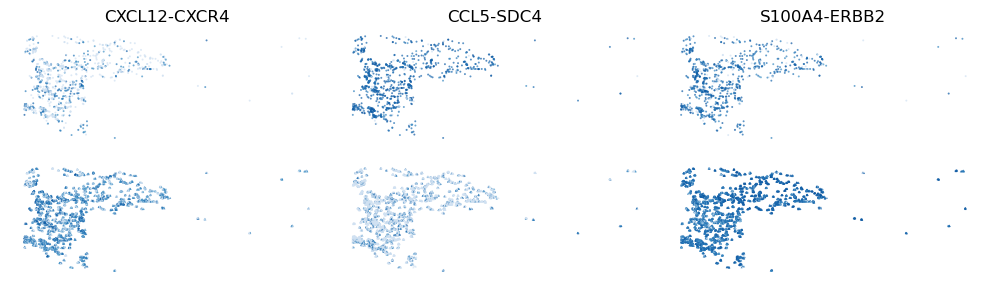

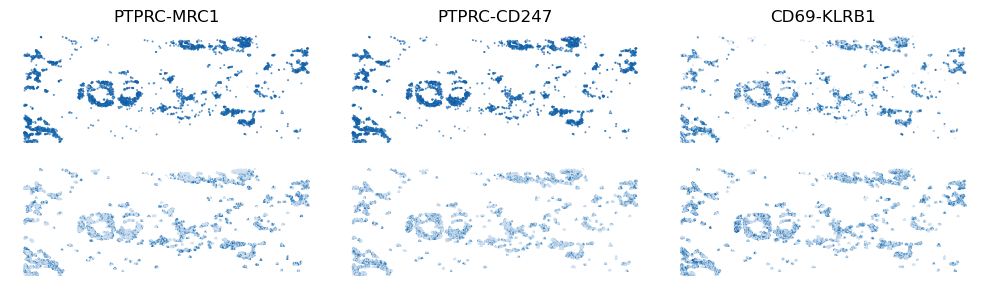

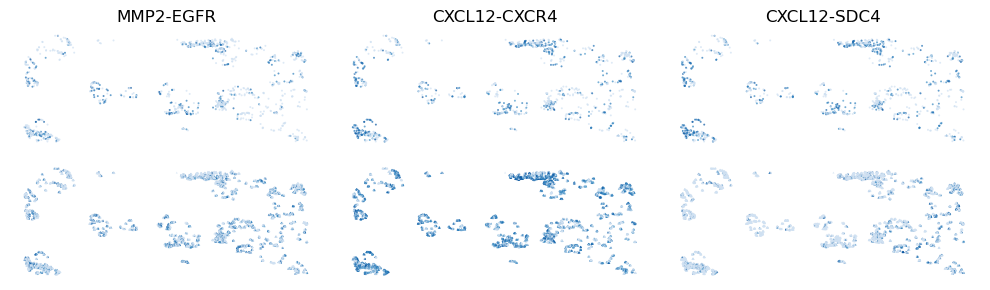

In [18]:
from matplotlib.colors import Normalize
def get_scanpy_spatial_limits(adata, spot_size=1e-9):
    fig, ax = plt.subplots()
    sc.pl.spatial(adata, color=None, spot_size=spot_size, frameon=False, ax=ax, show=False)
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    y_inv = ax.yaxis_inverted()
    plt.close(fig)
    return xlim, ylim, y_inv

def apply_axes_like_scanpy(ax, xlim, ylim, y_inv):
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    if y_inv and not ax.yaxis_inverted():
        ax.invert_yaxis()

# ------ 取某个基因表达向量 ------
def _get_gene_vec(adata, gene, use_raw=False, layer=None):
    if use_raw and (adata.raw is not None) and (gene in adata.raw.var_names):
        X = adata.raw[:, [gene]].X
    else:
        if gene not in adata.var_names:
            raise KeyError(f"'{gene}' 不在 adata.var_names（如在 raw，请设 use_raw=True）。")
        if layer is None:
            X = adata[:, [gene]].X
        else:
            X = adata[:, [gene]].layers[layer]
    if hasattr(X, "toarray"):
        X = X.toarray()
    return np.asarray(X).ravel()

# ------ 在与 scanpy 相同布局下按基因表达着色 ------
def spatial_gene_on_ax(
    adata, gene, *, in_col, nb_col, ax, limits,
    xy_key="spatial", focus="any", cmap="viridis",
    clip_mode="zero_aware", upper_q=0.98, clip_q=(0.02,0.98), min_pos_count=20,
    bg_color="#FFFFFF", sizes=(0.1, 2), alphas=(0.1,0.7),
    outline=False, outline_color="black", outline_width=0.35,
    title=None, add_colorbar=False, cbar_label=None,
    use_raw=False, layer=None
):
    # 坐标与掩码
    XY = np.asarray(adata.obsm[xy_key])[:, :2]
    x, y = XY[:,0], XY[:,1]
    m_in = adata.obs[in_col].astype(bool).to_numpy()
    m_nb = adata.obs[nb_col].astype(bool).to_numpy()
    if focus == "any":
        m_focus = (m_in | m_nb)
    elif focus == "in":
        m_focus = m_in
    elif focus == "nb":
        m_focus = m_nb
    else:
        raise ValueError("focus 必须是 'any' | 'in' | 'nb'")

    # 表达与颜色范围
    expr = _get_gene_vec(adata, gene, use_raw=use_raw, layer=layer)
    vals = expr[m_focus]; vals = vals[np.isfinite(vals)]
    if clip_mode == "zero_aware":
        vmin = 0.0
        pos = vals[vals > 0]
        vmax = float(np.quantile(pos, upper_q)) if pos.size >= min_pos_count else (float(pos.max()) if pos.size>0 else 1.0)
    elif clip_mode == "quantile":
        vmin, vmax = (float(np.quantile(vals, clip_q[0])), float(np.quantile(vals, clip_q[1]))) if vals.size else (0.0,1.0)
    else:
        vmin = float(np.nanmin(vals)) if vals.size else 0.0
        vmax = float(np.nanmax(vals)) if vals.size else 1.0
    if not np.isfinite(vmax) or vmax<=vmin: vmax = vmin+1.0
    norm = Normalize(vmin=vmin, vmax=vmax)

    S_BG,S_HI = sizes; A_BG,A_HI = alphas
    ec = outline_color if outline else "none"
    lw = outline_width if outline else 0.0

    # 背景
    ax.scatter(x[~m_focus], y[~m_focus], s=S_BG, c=bg_color, alpha=A_BG,
               linewidths=0, zorder=1, rasterized=True)

    # 域内（圆）
    m1 = m_in & m_focus
    sc1 = ax.scatter(x[m1], y[m1], s=S_HI, c=expr[m1], cmap=cmap, norm=norm,
                     marker="o", alpha=A_HI, linewidths=lw, edgecolors=ec,
                     zorder=3, rasterized=True)

    # 邻域（三角）
    m2 = m_nb & m_focus
    sc2 = ax.scatter(x[m2], y[m2], s=S_HI, c=expr[m2], cmap=cmap, norm=norm,
                     marker="^", alpha=A_HI, linewidths=lw, edgecolors=ec,
                     zorder=3, rasterized=True)

    # 坐标与标题
    xlim, ylim, y_inv = limits
    apply_axes_like_scanpy(ax, xlim, ylim, y_inv)
    if title: ax.set_title(title)

    # 可选色条
    if add_colorbar:
        sm = sc2 if np.any(m2) else sc1
        cbar = plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
        src = "raw" if use_raw else (f"layer='{layer}'" if layer is not None else "X")
        cbar.set_label(cbar_label or f"{gene} expression ({src})")
    def drop_box(ax):
        ax.set_axis_off()           # 等价于 plt.axis('off')
        ax.set_frame_on(False)
    for s in ax.spines.values():
        s.set_visible(False)

    for ax in axes.flat:            # axes 来自 fig, axes = plt.subplots(2, 3, ...)
        drop_box(ax)


limits = get_scanpy_spatial_limits(BC_filter)

from matplotlib import cm, colors
def truncate_cmap(name="Blues", low=0.20, high=0.85, N=256):
    base = cm.get_cmap(name, N)
    return colors.LinearSegmentedColormap.from_list(
        f"{name}_trunc", base(np.linspace(low, high, N))
    )

cm_blues = truncate_cmap("Blues", 0.20, 0.85)

fig, axes = plt.subplots(2, 3, figsize=(10, 3))

# Column 1: Vip(in) / Ramp1(nb)

spatial_gene_on_ax(
    BC_filter, "CXCL12",
    in_col="in_CD8_niche_1", nb_col="is_neighbor_CD8_niche_1",
    ax=axes[0,0], limits=limits, focus="in", cmap=cm_blues,
    upper_q=0.98, title="CXCL12-CXCR4"
)
spatial_gene_on_ax(
    BC_filter, "CXCR4",
    in_col="in_CD8_niche_1", nb_col="is_neighbor_CD8_niche_1",
    ax=axes[1,0], limits=limits, focus="nb", cmap=cm_blues,
    upper_q=0.98, title=None
)

spatial_gene_on_ax(
    BC_filter, "CCL5",
    in_col="in_CD8_niche_1", nb_col="is_neighbor_CD8_niche_1",
    ax=axes[0,1], limits=limits, focus="in", cmap=cm_blues,
    upper_q=0.98, title="CCL5-SDC4"
)
spatial_gene_on_ax(
    BC_filter, "SDC4",
    in_col="in_CD8_niche_1", nb_col="is_neighbor_CD8_niche_1",
    ax=axes[1,1], limits=limits, focus="nb", cmap=cm_blues,
    upper_q=0.98, title=None
)

# Column 3: Dscaml1(in) / Ptprk(nb)
spatial_gene_on_ax(
    BC_filter, "S100A4",
    in_col="in_CD8_niche_1", nb_col="is_neighbor_CD8_niche_1",
    ax=axes[0,2], limits=limits, focus="in", cmap=cm_blues,
    upper_q=0.98, title="S100A4-ERBB2"
)
spatial_gene_on_ax(
    BC_filter, "ERBB2",
    in_col="in_CD8_niche_1", nb_col="is_neighbor_CD8_niche_1",
    ax=axes[1,2], limits=limits, focus="nb", cmap=cm_blues,
    upper_q=0.98, title=None
)


plt.tight_layout()
plt.show()



fig, axes = plt.subplots(2, 3, figsize=(10, 3))

# Column 1: Vip(in) / Ramp1(nb)

spatial_gene_on_ax(
    BC_filter, "PTPRC",
    in_col="in_CD8_niche_2", nb_col="is_neighbor_CD8_niche_2",
    ax=axes[0,0], limits=limits, focus="in", cmap=cm_blues,
    upper_q=0.98, title="PTPRC-MRC1"
)
spatial_gene_on_ax(
    BC_filter, "MRC1",
    in_col="in_CD8_niche_2", nb_col="is_neighbor_CD8_niche_2",
    ax=axes[1,0], limits=limits, focus="nb", cmap=cm_blues,
    upper_q=0.98, title=None
)

spatial_gene_on_ax(
    BC_filter, "PTPRC",
    in_col="in_CD8_niche_2", nb_col="is_neighbor_CD8_niche_2",
    ax=axes[0,1], limits=limits, focus="in", cmap=cm_blues,
    upper_q=0.98, title="PTPRC-CD247"
)
spatial_gene_on_ax(
    BC_filter, "CD247",
    in_col="in_CD8_niche_2", nb_col="is_neighbor_CD8_niche_2",
    ax=axes[1,1], limits=limits, focus="nb", cmap=cm_blues,
    upper_q=0.98, title=None
)

# Column 3: Dscaml1(in) / Ptprk(nb)
spatial_gene_on_ax(
    BC_filter, "CD69",
    in_col="in_CD8_niche_2", nb_col="is_neighbor_CD8_niche_2",
    ax=axes[0,2], limits=limits, focus="in", cmap=cm_blues,
    upper_q=0.98, title="CD69-KLRB1"
)
spatial_gene_on_ax(
    BC_filter, "KLRB1",
    in_col="in_CD8_niche_2", nb_col="is_neighbor_CD8_niche_2",
    ax=axes[1,2], limits=limits, focus="nb", cmap=cm_blues,
    upper_q=0.98, title=None
)


plt.tight_layout()
plt.show()

########## Niche 7
fig, axes = plt.subplots(2, 3, figsize=(10, 3))

# Column 1: Vip(in) / Ramp1(nb)

spatial_gene_on_ax(
    BC_filter, "MMP2",
    in_col="in_CD8_niche_7", nb_col="is_neighbor_CD8_niche_7",
    ax=axes[0,0], limits=limits, focus="in", cmap=cm_blues,
    upper_q=0.98, title="MMP2-EGFR"
)
spatial_gene_on_ax(
    BC_filter, "EGFR",
    in_col="in_CD8_niche_7", nb_col="is_neighbor_CD8_niche_7",
    ax=axes[1,0], limits=limits, focus="nb", cmap=cm_blues,
    upper_q=0.98, title=None
)

spatial_gene_on_ax(
    BC_filter, "CXCL12",
    in_col="in_CD8_niche_7", nb_col="is_neighbor_CD8_niche_7",
    ax=axes[0,1], limits=limits, focus="in", cmap=cm_blues,
    upper_q=0.98, title="CXCL12-CXCR4"
)
spatial_gene_on_ax(
    BC_filter, "CXCR4",
    in_col="in_CD8_niche_7", nb_col="is_neighbor_CD8_niche_7",
    ax=axes[1,1], limits=limits, focus="nb", cmap=cm_blues,
    upper_q=0.98, title=None
)

# Column 3: Dscaml1(in) / Ptprk(nb)
spatial_gene_on_ax(
    BC_filter, "CXCL12",
    in_col="in_CD8_niche_7", nb_col="is_neighbor_CD8_niche_7",
    ax=axes[0,2], limits=limits, focus="in", cmap=cm_blues,
    upper_q=0.98, title="CXCL12-SDC4"
)
spatial_gene_on_ax(
    BC_filter, "SDC4",
    in_col="in_CD8_niche_7", nb_col="is_neighbor_CD8_niche_7",
    ax=axes[1,2], limits=limits, focus="nb", cmap=cm_blues,
    upper_q=0.98, title=None
)


plt.tight_layout()
plt.show()